# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [1]:
import os

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 200)

import pickle


import importlib
import html_tools
import funcs

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-05-09 09:00:44.484487: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-09 09:00:44.666867: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compi

In [2]:
importlib.reload(funcs)

<module 'funcs' from '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/funcs.py'>

## Chargement des données

Les données sont obtenues avec la requête SQL suivante :

``` sql
DECLARE @start_date DATE
DECLARE @end_date DATE
SET @start_date = '2011-01-01'
SET @end_date = DATEADD(year, 1, @start_date)

SELECT Id, CreationDate, Title, Body, Tags, ViewCount, FavoriteCount, CommentCount, AnswerCount, Score
FROM Posts
WHERE (PostTypeID = 1)
AND (CreationDate BETWEEN @start_date AND @end_date)
AND ViewCount > 10
AND CommentCount > 3
AND AnswerCount > 0
AND Score > 5
AND len(Tags) > 0
```

La variable `@start_date` est modifiée jusqu'à 2020-01-01.

In [3]:
funcs.print_listdir( exclude=['.venv', 'ressources', 'Figures'] )

print('| ----------- |')
df = funcs.load_data()
display(df.info())
years_0 = df['CreationDate'].dt.year.unique()
years_0.sort()

 .vscode
 |- settings.json
 API_TDT_stackoverflow
 |- .git
 |- |- COMMIT_EDITMSG
 |- |- HEAD
 |- |- branches
 |- |- config
 |- |- description
 |- |- hooks
 |- |- |- applypatch-msg.sample
 |- |- |- commit-msg.sample
 |- |- |- fsmonitor-watchman.sample
 |- |- |- post-update.sample
 |- |- |- pre-applypatch.sample
 |- |- |- pre-commit.sample
 |- |- |- pre-merge-commit.sample
 |- |- |- pre-push.sample
 |- |- |- pre-rebase.sample
 |- |- |- pre-receive.sample
 |- |- |- prepare-commit-msg.sample
 |- |- |- push-to-checkout.sample
 |- |- |- update.sample
 |- |- index
 |- |- info
 |- |- |- exclude
 |- |- logs
 |- |- |- HEAD
 |- |- |- refs
 |- |- |- |- heads
 |- |- |- |- |- main
 |- |- |- |- remotes
 |- |- |- |- |- origin
 |- |- |- |- |- |- main
 |- |- objects
 |- |- |- 02
 |- |- |- |- 745e543ef7efdc04a4b5cd44a96b7d708cf0e8
 |- |- |- 0d
 |- |- |- |- b3cb1b694a9cac44512c341b1a12c06000b81f
 |- |- |- 0e
 |- |- |- |- 3e9d7a2b903f3246f5333d45520d0742ae3d74
 |- |- |- 15
 |- |- |- |- e87671610becb4bdc1ab

None

Dupplicate entries: 0


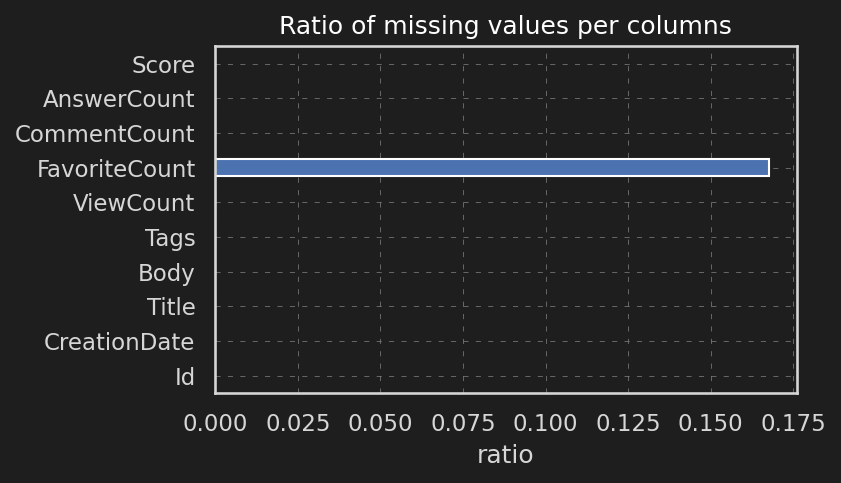

In [4]:
print('Dupplicate entries: {}'.format(df.duplicated().sum()))

ax = df.isnull().mean(axis=0).plot.barh()
ax.set_title("Ratio of missing values per columns")
ax.set_xlabel('ratio')
fig = ax.get_figure()
fig.set_size_inches(5,3)

# Exploration

## Longueur des titres et corps de textes

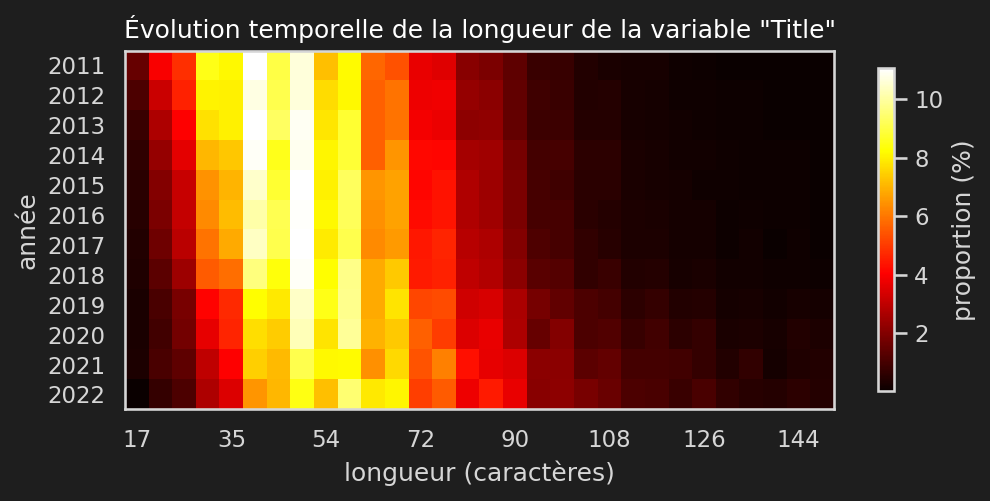

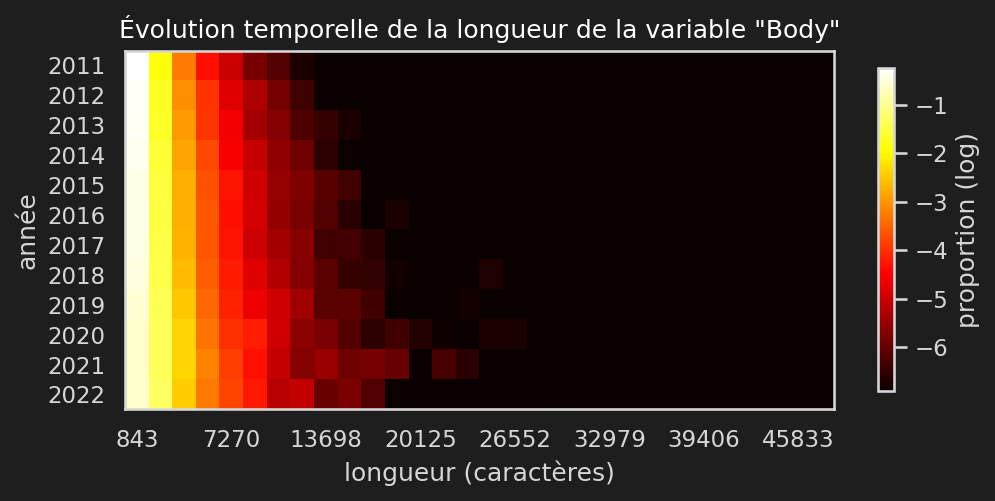

In [5]:
years = df['CreationDate'].dt.year
len_per_year = {var: funcs.length_per_year(df[var], years)
                for var in ['Title', 'Body']
                }
del years

funcs.plot_array_len_per_year(*(len_per_year['Title']), 'Title')
funcs.plot_array_len_per_year(*(len_per_year['Body']), 'Body', log=True)

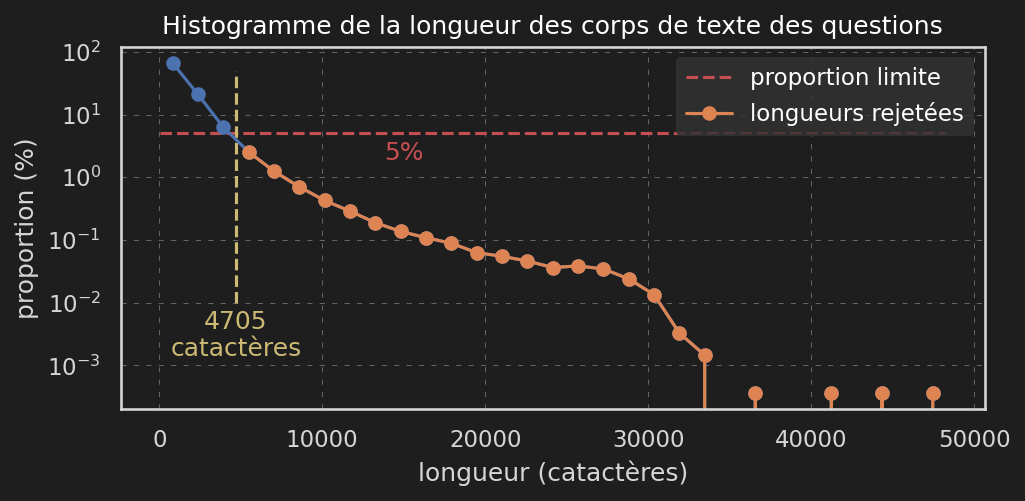

In [6]:
funcs.plot_histogram_longueur_texte(df['Body'])

## html tags

In [7]:
print(df['Body'].iloc[3])

x = funcs.clean_body(df['Body'].iloc[:10])
print(funcs.remove_html(df['Body'].iloc[0]))
print(x.iloc[0])

<p>Okay, I got a website where you can register yourself and login. You can also login with your facebook, twitter or linkedin account.</p>

<p>It is important that users only have one account registered. So somehow, I want to merge the accounts of users if they use different methods to login. What is the best solution to solve this?</p>

<p>For instance, the user logs in with his Facebook account. I use the data to register an account for him automatically. Should I sent an e-mail with an username and password of our website? (If this is okay with the policy of Facebook). Should I give them a second screen where they can fill in an username and password? But that's not the idea behind logging in with your Facebook account. It should simplify your procedure to participate.</p>

<p>It's also possible the user has registered himself on our website and the next time he logs in with his twitter account. How can I merge these 2 accounts as one? What's the best way?</p>

<p>So basically my q

In [8]:
importlib.reload(funcs)
html_tags = funcs.get_html_tags(df['Body'].iloc[:10])
print('found html tags:', html_tags)

100% 
found html tags: {'code', 'h2', 'li', 'pre', 'em', 'h3', 'strong', 'p', 'blockquote', 'ul'}


# Extraction et décompte des tags

In [9]:
print('initial tags column:')
display(df['Tags'].iloc[:10])

initial tags column:


0                  <c#><.net><winforms><user-controls>
1    <c#><asp.net><asp.net-mvc><web-services><excep...
2      <python><proxy><mechanize><web-scraping><errno>
3        <architecture><oauth><openid><multiple-login>
4                               <c#><oop><refactoring>
5                                  <node.js><timezone>
6                                     <java><ip><wifi>
7      <javascript><jquery><html><css><jquery-plugins>
8    <python><arrays><image-processing><numpy><rota...
9                                    <localhost><wamp>
Name: Tags, dtype: object

In [10]:
df['Tags'] = funcs.init_tag(df['Tags'])
print('modified tags column:')
display(df['Tags'].iloc[:10])

modified tags column:


0                  [c#, .net, winforms, user-controls]
1    [c#, asp.net, asp.net-mvc, web-services, excep...
2      [python, proxy, mechanize, web-scraping, errno]
3        [architecture, oauth, openid, multiple-login]
4                               [c#, oop, refactoring]
5                                  [node.js, timezone]
6                                     [java, ip, wifi]
7      [javascript, jquery, html, css, jquery-plugins]
8    [python, arrays, image-processing, numpy, rota...
9                                    [localhost, wamp]
Name: Tags, dtype: object

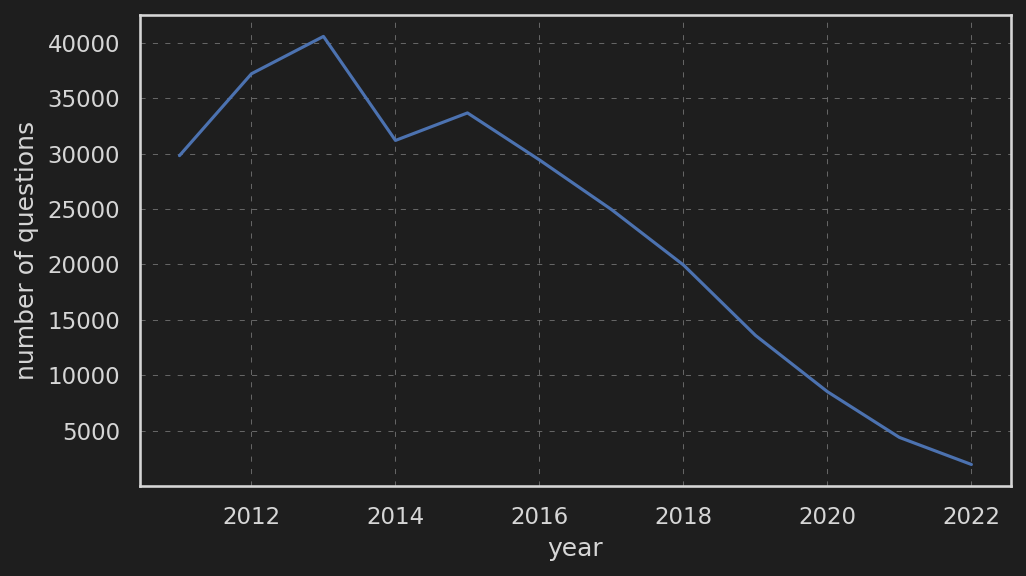

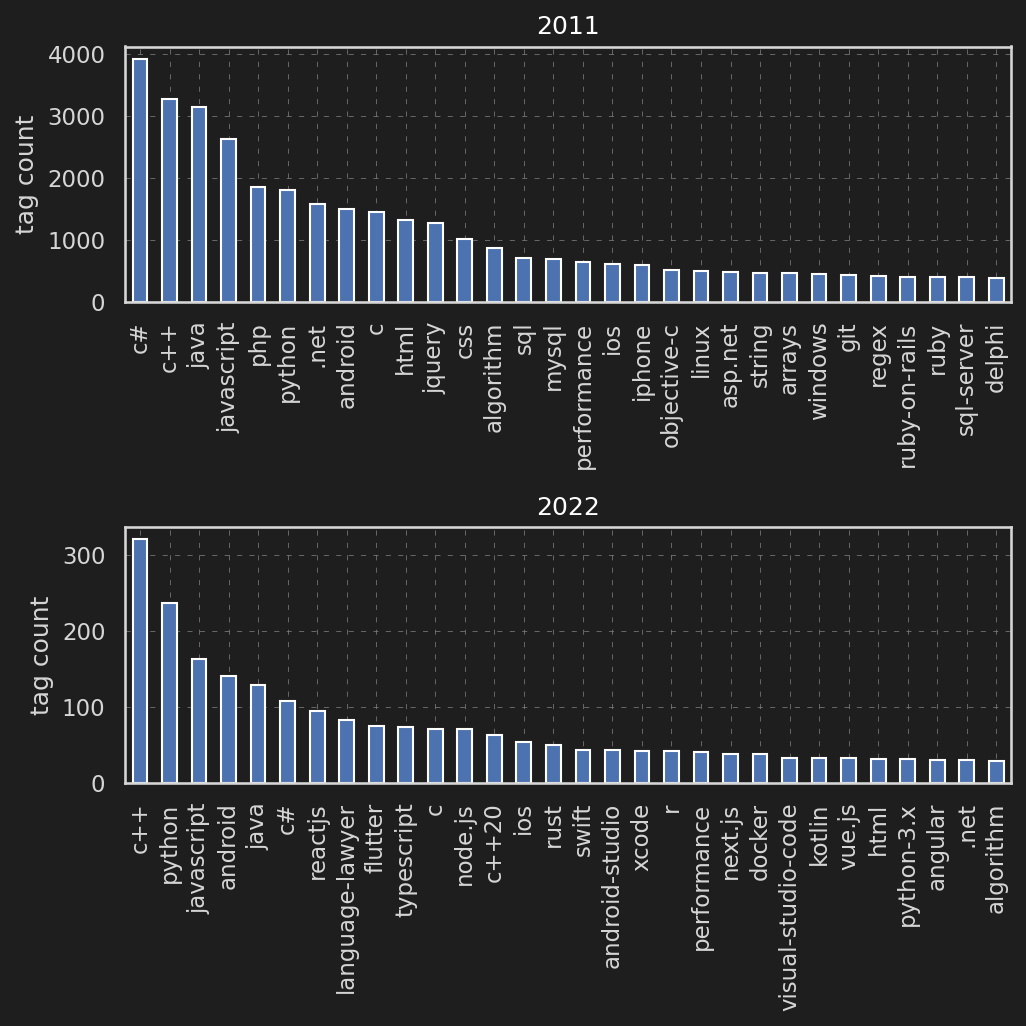

In [11]:
importlib.reload(funcs)
tags = {}
tags['per year'], questions_per_year = funcs.count_tags_and_questions_per_year(df)
funcs.plot_questions_per_year(questions_per_year)
funcs.plot_tags_most_present(tags['per year'])

## Extraction des tags les plus présents

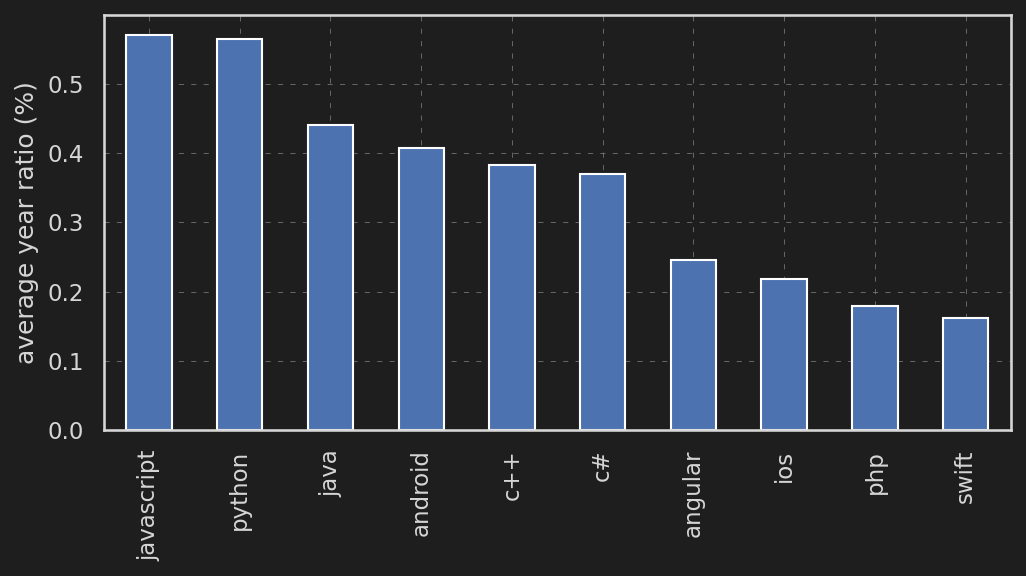

In [12]:
years = funcs.compute_most_used_tags(tags, n_tags=10, year_min=2017)
funcs.plot_most_used_tags(tags)

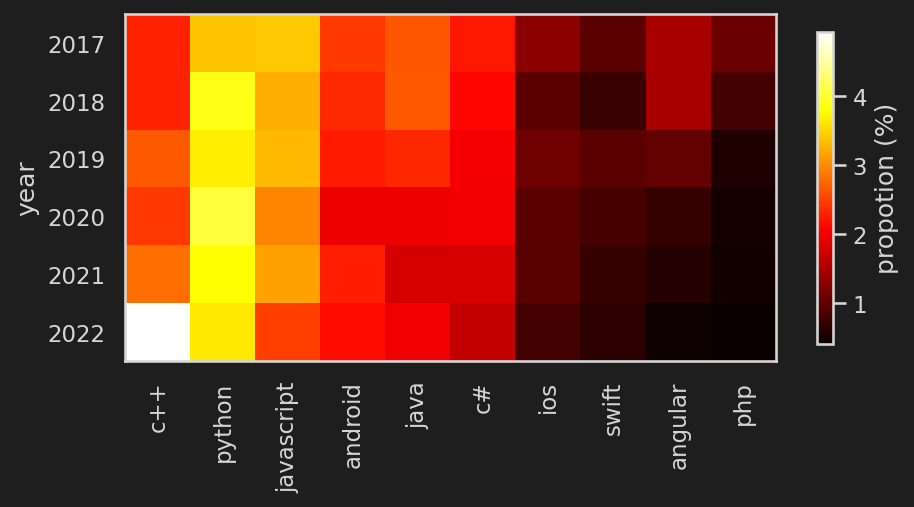

In [13]:
funcs.plot_propotion_most_used_tags_per_year(tags['per year'],
                                             tags['most used'].index.tolist(),
                                             years)

On peut noter que :
* la proportion de tags "`python`" reste approximativement stable dans le temps
* certaines proportion augmentent dans sur la période, comme "`reactjs`" ou "`c++`"
* d'autres diminue, come "`c++11`"

In [14]:
path_save = 'data/cleaned/'
with open(path_save + 'dico_tags', 'wb') as file:
    pickle.dump(tags, file)

## Suppression des tags non sélectionnés

In [15]:
df2 = funcs.apply_tag_filtering(df, years, tags['most used'].index.tolist())

Total number of questions: 275325
Number of questions since 2017: 73362


,Title,Tags
0,Cannot Place User Control on Form,"['c#', '.net', 'winforms', 'user-controls']"
1,SoapException Server was unable to process request on ASMX webservice in MVC site,"['c#', 'asp.net', 'asp.net-mvc', 'web-services', 'exception']"
2,Python urlopen connection aborted - urlopen error [Errno 10053],"['python', 'proxy', 'mechanize', 'web-scraping', 'errno']"
3,Architecture for merging multiple user accounts together,"['architecture', 'oauth', 'openid', 'multiple-login']"
4,Is it OK to have a class with just properties for refactoring purposes?,"['c#', 'oop', 'refactoring']"


,Title,Tags
0,Cannot Place User Control on Form,['c#']
1,SoapException Server was unable to process request on ASMX webservice in MVC site,['c#']
2,Python urlopen connection aborted - urlopen error [Errno 10053],['python']
3,Architecture for merging multiple user accounts together,nan
4,Is it OK to have a class with just properties for refactoring purposes?,['c#']


,Title,Tags
0,Cannot Place User Control on Form,['c#']
1,SoapException Server was unable to process request on ASMX webservice in MVC site,['c#']
2,Python urlopen connection aborted - urlopen error [Errno 10053],['python']
4,Is it OK to have a class with just properties for refactoring purposes?,['c#']
6,Java getting my IP address,['java']


Total number of questions with Tags filtered: 173255
Number of questions with Tags filtered since 2017: 45711


In [16]:
df = df2

In [18]:
tmp = tags['most used'].index.tolist()[0]
y_tag = funcs.compute_y_tag(df['Tags'], tmp).astype(int)

df_tags = funcs.multi_label_binarize(df['Tags'],
                                     tags['most used'].index.tolist())
display(df_tags)

print("nombre d'entrées:", len(df_tags))
print("nombre d'entrées avec 0 tag:", (df_tags.sum(axis=1) == 0).sum() )
print("nombre d'entrées avec plus de 1 tag:", (df_tags.sum(axis=1) > 1).sum() )

,javascript,python,java,android,c++,c#,angular,ios,php,swift
0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
173250,0,1,0,0,0,0,0,0,0,0
173251,0,1,0,0,0,0,0,0,0,0
173252,0,0,0,0,1,0,0,0,0,0
173253,0,1,0,0,0,0,0,0,0,0


nombre d'entrées: 173255
nombre d'entrées avec 0 tag: 0
nombre d'entrées avec plus de 1 tag: 10441


On note que seulement 6% des entrés on plus d'un tag.

# Traitement des "Title" et "Body"

In [16]:
tmp = df['Body'].iloc[2]
print(tmp)

# print(html_tools.extract_elements(tmp, 'code'))
# print(html_tools.remove_element(tmp, 'code'))

<p>I have some code that uses mechanize and beautifulsoup for web scraping some data. The code works fine on a test machine but the production machine is blocking the connection. The error i get is:</p>

<pre><code>urlopen error [Errno 10053] An established connection was aborted by the software in your host machine
</code></pre>

<p>I have read through similar posts and I cannot find this exact error. The site I am trying to scrape is HTTPS but I have also had the same error occur with an HTTP site. I am using python 2.6 and mechanize 0.2.4. </p>

<p>Is this due to the proxy or, as the error says, something on my local machine??
I've written in for mechanize to use the system's proxy:</p>

<pre><code>br = mechanize.Browser()
br.addheaders = [('User-agent', 'Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1')]
br.set_proxies({}) #will use system default proxy
page = br.open(url)
html = page.read()
soup = BeautifulSoup.BeautifulSoup(html)
</code></pre>

<p>Again, this all works on my te

In [17]:
df['Body_clean'] = funcs.clean_body(df['Body'])
df['Title_clean'] = funcs.clean_body(df['Title'])

In [18]:
i = 0
tmp = df['Body'].iloc[i]
print(tmp)
print('\n| ------ |\n')
tmp = df['Body_clean'].iloc[i]
print(tmp)

<p>I've created a C# WinForms application using VS2010. I'm new to creating user controls so I created a new user control (as part of the same project).</p>

<p>When I rebuild the project, the new control appears in the toolbox. And when I drag the control from the toolbox onto a form, I get the following error.</p>

<blockquote>
  <p>Failed to load toolbox item 'TagGroup'.  It will be removed from the toolbox.</p>
</blockquote>

<p>This happened the only other time I created a user control as well. I've searched the web but most answers I found seemed related to having the control in a separate assembly. (Note that I found plenty of questions with the same problem I'm having.)</p>

<p>Can anyone suggest where I should look next?</p>


| ------ |

i have created a c# winforms application using vs2010. i am new to creating user controls so i created a new user control (as part of the same project).

when i rebuild the project, the new control appears in the toolbox. and when i drag the 

In [19]:
i = 1
tmp = df['Body'].iloc[i]
print(tmp)
print('\n| ------ |\n')
tmp = df['Body_clean'].iloc[i]
print(tmp)

<p>I'm getting an exception when trying to access an .asmx webservice within a MVC site.  I've tried numerous things like updating the web reference within the console application and building another quick app to test, but can't get passed this issue.  If I pull the URL out of the svc variable, I can browse to it directly.</p>

<h2>Exception Details</h2>

<blockquote>
  <p>System.Web.Services.Protocols.SoapException
  occurred   Message=Server was unable
  to process request. ---> Value cannot
  be null. Parameter name: uriString<br>
  Source=System.Web.Services   Actor="" 
  Lang=""   Node=""   Role=""<br>
  StackTrace:
         at System.Web.Services.Protocols.SoapHttpClientProtocol.ReadResponse(SoapClientMessage
  message, WebResponse response, Stream
  responseStream, Boolean asyncCall)
         at System.Web.Services.Protocols.SoapHttpClientProtocol.Invoke(String
  methodName, Object[] parameters)
         at ClarityIntegration.SendTrackerDataToClarity()
  in [REDACTED].Reference

In [20]:
importlib.reload(funcs)
def test_preprocess(text, most_used_tags):
    print('Raw text:\n', text)
    tokens = funcs.tokenize(text, most_used_tags)
    print('Tokenized text:\n', tokens)
    lemma = funcs.lemmatize(tokens, most_used_tags)
    print('Lemmatized text:\n', lemma, )
    stem = funcs.stem(tokens, most_used_tags)
    print('stemmed text:\n', stem)


most_used_tags = tags['most used'].index.tolist()
for i in range(10):
    if i > 0 :
        print('\n| ----------- |\n')
    tmp = df['Body_clean'].iloc[i]
    text = tmp[:100]
    test_preprocess(text, most_used_tags)

Raw text:
 i have created a c# winforms application using vs2010. i am new to creating user controls so i creat
Tokenized text:
 ['created', 'c#', 'winforms', 'application', 'using', 'vs2010', 'new', 'creating', 'user', 'controls', 'creat']
Lemmatized text:
 ['created', 'c#', 'winforms', 'application', 'using', 'vs2010', 'new', 'creating', 'user', 'control', 'creat']
stemmed text:
 ['creat', 'c#', 'winform', 'applic', 'use', 'vs2010', 'new', 'creat', 'user', 'control', 'creat']

| ----------- |

Raw text:
 i am getting an exception when trying to access an .asmx webservice within a mvc site.  i have tried
Tokenized text:
 ['getting', 'exception', 'trying', 'access', 'asmx', 'webservice', 'within', 'mvc', 'site', 'tried']
Lemmatized text:
 ['getting', 'exception', 'trying', 'access', 'asmx', 'webservice', 'within', 'mvc', 'site', 'tried']
stemmed text:
 ['get', 'except', 'tri', 'access', 'asmx', 'webservic', 'within', 'mvc', 'site', 'tri']

| ----------- |

Raw text:
 i have some code t

In [21]:
def process_text(text, tags):
    return ' '.join(funcs.lemmatize(funcs.tokenize(text, tags), tags))

df['Title_processed'] = df['Title_clean'].apply(lambda x: process_text(x, most_used_tags))
df['Body_processed'] = df['Body_clean'].apply(lambda x: process_text(x, most_used_tags))

In [22]:
df['Title_processed'].iloc[0]

'cannot place user control form'

In [23]:
features = ['Title_clean', 'Title_processed', 'Body_clean', 'Body_processed', 'Tags']
# df[features].to_csv(path_save + 'data.csv')
df[features].to_pickle(path_save + 'data.pickle')